### Applied Partial Differential Equations | Richard Haberman | Solutions and Code by David A. Lee
### Chapter 3: Fourier Series
#### Section 3.3: Fourier Cosine and Sine Series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim

Question 3.3.1

In [2]:
def style_ax(ax, xlabel='$x$', ylabel='$y$', xlim=None, ylim=None,
             xticks=None, xticklabels=None, yticks=None, yticklabels=None,
             color=FG, fontsize=16):
    """Apply shared plot attributes to one or more axes."""
    axes = np.atleast_1d(ax)
    for a in axes:
        a.set_xlabel(xlabel, color=color, fontsize=fontsize)
        a.set_ylabel(ylabel, color=color, fontsize=fontsize)
        a.tick_params(colors=color)
        a.tick_params(labelsize=fontsize)
        a.tick_params(which='minor', top=False, bottom=False, left=False, right=False)
        a.grid(False)
        if xlim is not None:
            a.set_xlim(xlim)
        if ylim is not None:
            a.set_ylim(ylim)
        if xticks is not None:
            a.set_xticks(xticks)
        if xticklabels is not None:
            a.set_xticklabels(xticklabels, color=color)
        if yticks is not None:
            a.set_yticks(yticks)
        if yticklabels is not None:
            a.set_yticklabels(yticklabels, color=color)

In [3]:
L = 1.0
PERIODS = range(-2, 2)   # copies of (-L, L) covering [-3L, 3L]

L_ticks = [-3*L, -2*L, -L, 0, L, 2*L, 3*L]
L_labels = [r'$-3L$', r'$-2L$', r'$-L$', r'$0$', r'$L$', r'$2L$', r'$3L$']


def split_at_zero(pieces):
    """Ensure x = 0 is a piece boundary so the (0, L) half can be extracted."""
    out = []
    for a, b, g in pieces:
        if a < 0 < b:
            out += [(a, 0.0, g), (0.0, b, g)]
        else:
            out.append((a, b, g))
    return out


def odd_extension(pieces):
    """Fourier sine series converges to the odd, 2L-periodic extension of f on (0, L)."""
    right = [(a, b, g) for a, b, g in split_at_zero(pieces) if a >= 0]
    return [(-b, -a, (lambda g: lambda x: -g(-x))(g)) for a, b, g in right] + right


def even_extension(pieces):
    """Fourier cosine series converges to the even, 2L-periodic extension of f on (0, L)."""
    right = [(a, b, g) for a, b, g in split_at_zero(pieces) if a >= 0]
    return [(-b, -a, (lambda g: lambda x: g(-x))(g)) for a, b, g in right] + right


def draw_periodic(ax, pieces, color, label):
    """2L-periodic extension of pieces on [-3L, 3L], with jump markers
    (open circles = one-sided limits, filled dot = midpoint the series converges to)."""
    vals = []
    for k in PERIODS:
        for a, b, g in pieces:
            x = np.linspace(a, b, 400)
            y = g(x)
            vals.append(y)
            ax.plot(x + 2*k*L, y, color=color, linewidth=2.5)
    ax.plot([], [], color=color, linewidth=2.5, label=label)

    lefts  = {b: g(b) for a, b, g in pieces}   # limit from the left at x = b
    rights = {a: g(a) for a, b, g in pieces}   # limit from the right at x = a
    lefts[-L], rights[L] = lefts[L], rights[-L]  # periodicity wraps the ends
    for x0 in sorted(rights):
        lo, hi = lefts[x0], rights[x0]
        if not np.isclose(lo, hi):
            for k in PERIODS:
                xs = x0 + 2*k*L
                if -3*L <= xs <= 3*L:
                    ax.plot([xs, xs], [lo, hi], color=color, linestyle=':', linewidth=1)
                    ax.plot([xs, xs], [lo, hi], 'o', color=BG, markeredgecolor=color, markersize=6)
                    ax.plot(xs, (lo + hi)/2, 'o', color=color, markersize=6)
    return np.concatenate(vals)


def plot_all_series(pieces, label, fname, colors):
    """Rows: f on [-L, L]; Fourier series; Fourier sine series; Fourier cosine series."""
    fig, ax = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

    # row 0: f itself, only on [-L, L]
    vals = []
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        y = g(x)
        vals.append(y)
        ax[0].plot(x, y, color=colors[0], linewidth=2.5)
    ax[0].plot([], [], color=colors[0], linewidth=2.5, label=label)

    # rows 1-3: the three periodic extensions
    vals.append(draw_periodic(ax[1], pieces, colors[1], 'Fourier series'))
    vals.append(draw_periodic(ax[2], odd_extension(pieces), colors[2], 'Fourier sine series'))
    vals.append(draw_periodic(ax[3], even_extension(pieces), colors[3], 'Fourier cosine series'))

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    ylim = (v.min() - pad, v.max() + pad)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=ylim,
             xticks=L_ticks, xticklabels=L_labels)
    ax[0].set_ylabel('$f(x)$', color=FG, fontsize=16)
    ax[3].set_xlabel('$x$', color=FG, fontsize=16)
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color=FG, linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

(a)

saved chap3sec3.3ex1a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex1a.pdf


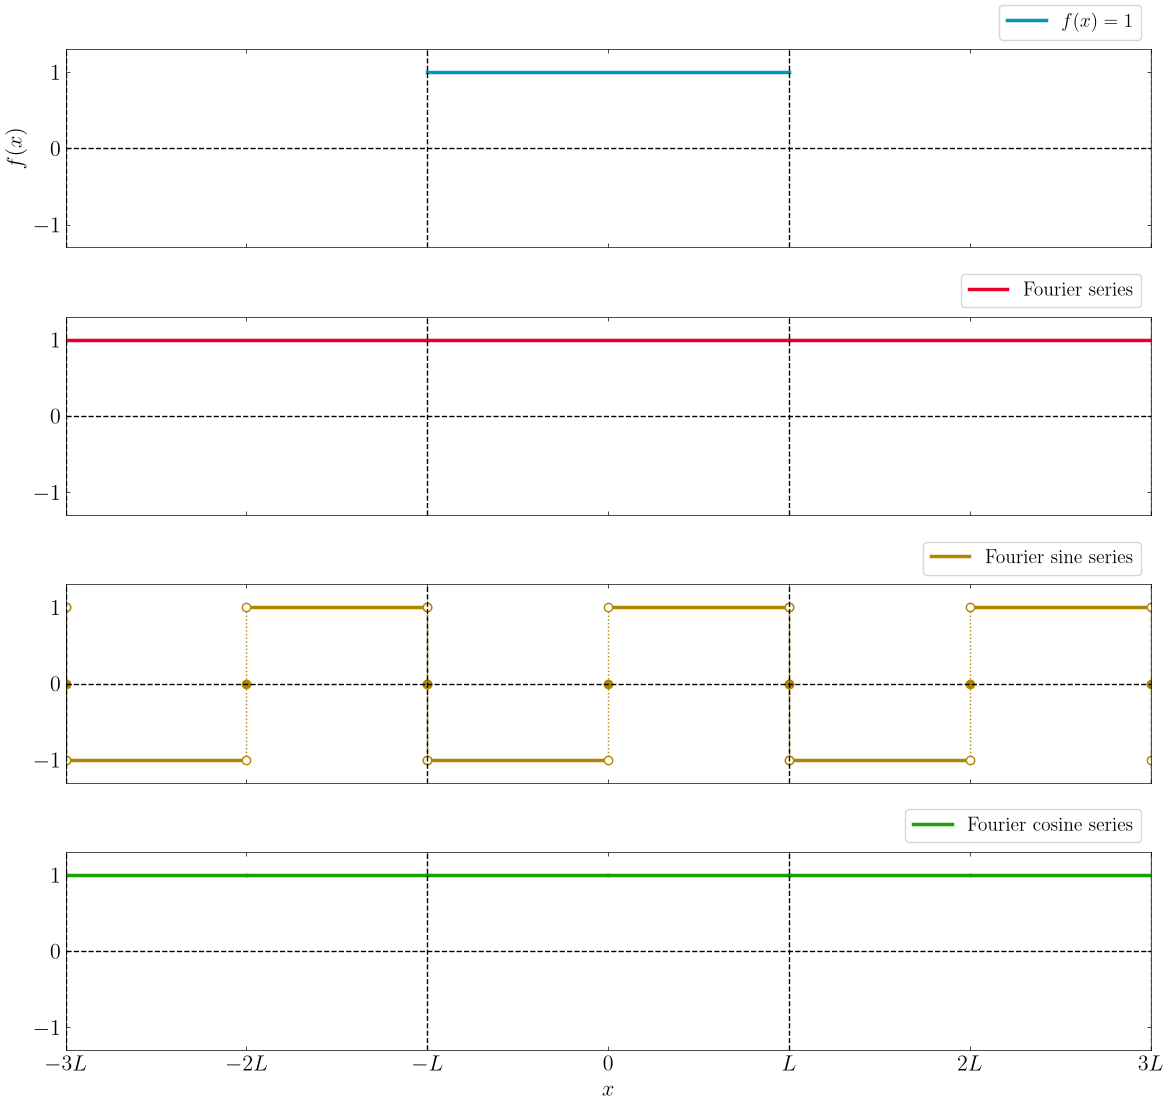

In [4]:
pieces = [(-L, L, lambda x: np.ones_like(x))]
plot_all_series(pieces, r"$f(x) = 1$", "chap3sec3.3ex1a.pdf", [C.cyan, C.red, C.yellow, C.green])

(b)

saved chap3sec3.3ex1b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex1b.pdf


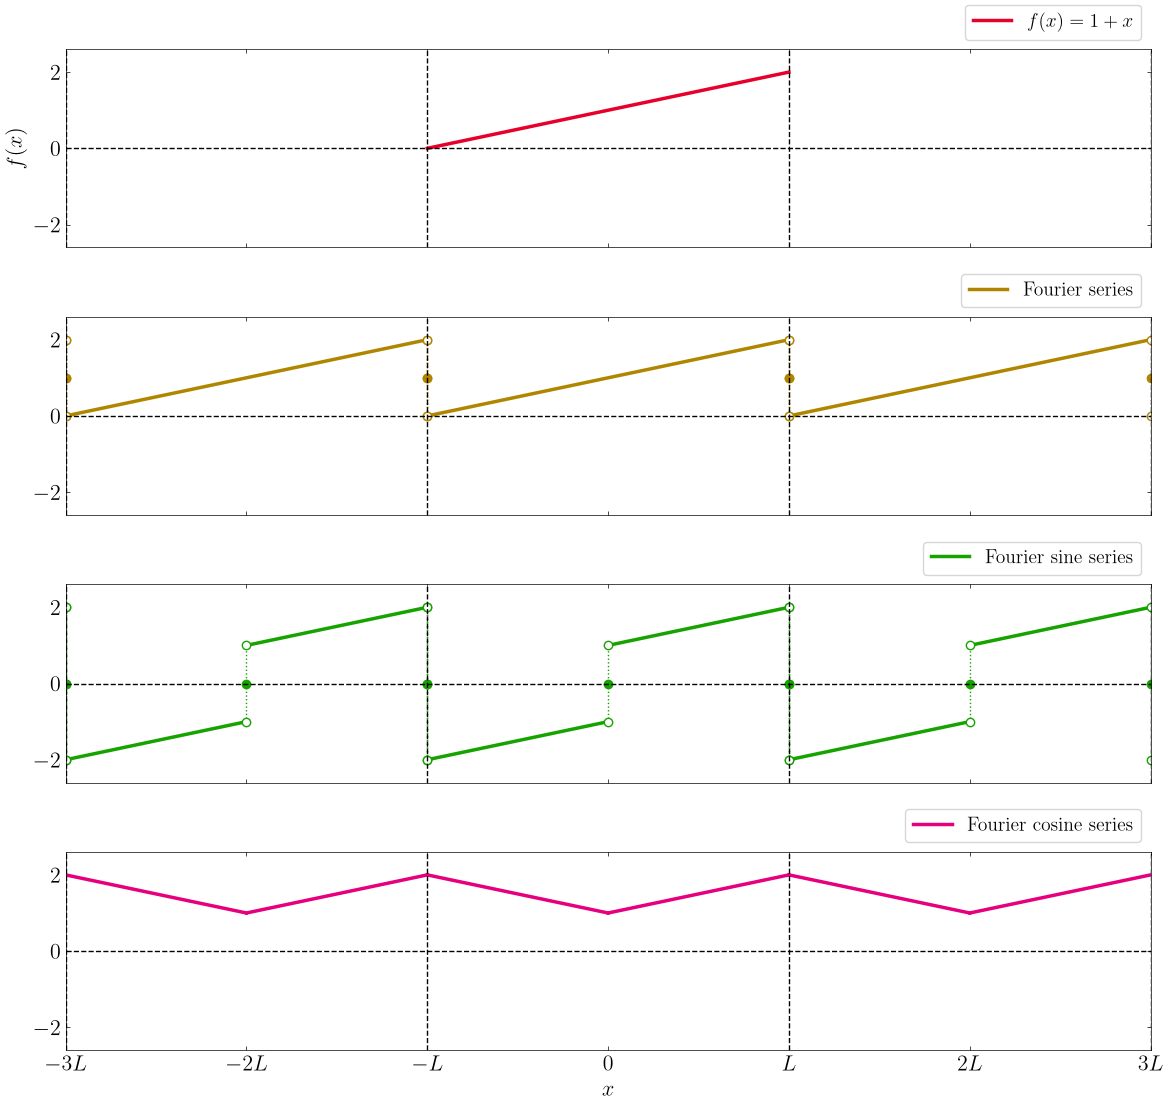

In [5]:
pieces = [(-L, L, lambda x: 1 + x)]
plot_all_series(pieces, r"$f(x) = 1 + x$", "chap3sec3.3ex1b.pdf", [C.red, C.yellow, C.green, C.magenta])

(c)

saved chap3sec3.3ex1c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex1c.pdf


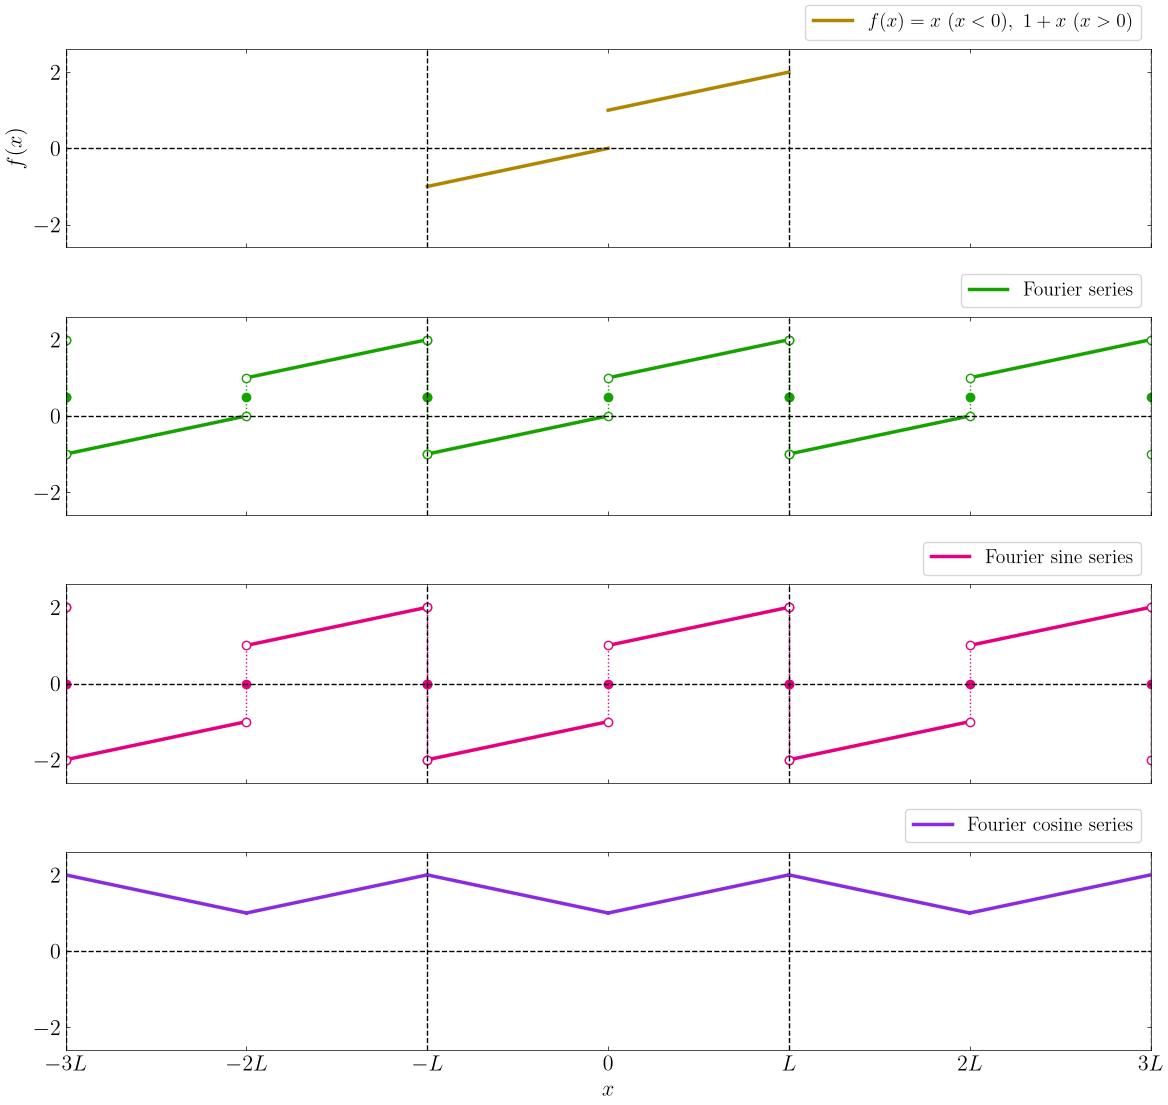

In [6]:
pieces = [(-L, 0, lambda x: x), (0, L, lambda x: 1 + x)]
plot_all_series(pieces, r"$f(x) = x\ (x<0),\ 1 + x\ (x>0)$", "chap3sec3.3ex1c.pdf", [C.yellow, C.green, C.magenta, C.violet])

(d)

saved chap3sec3.3ex1d.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex1d.pdf


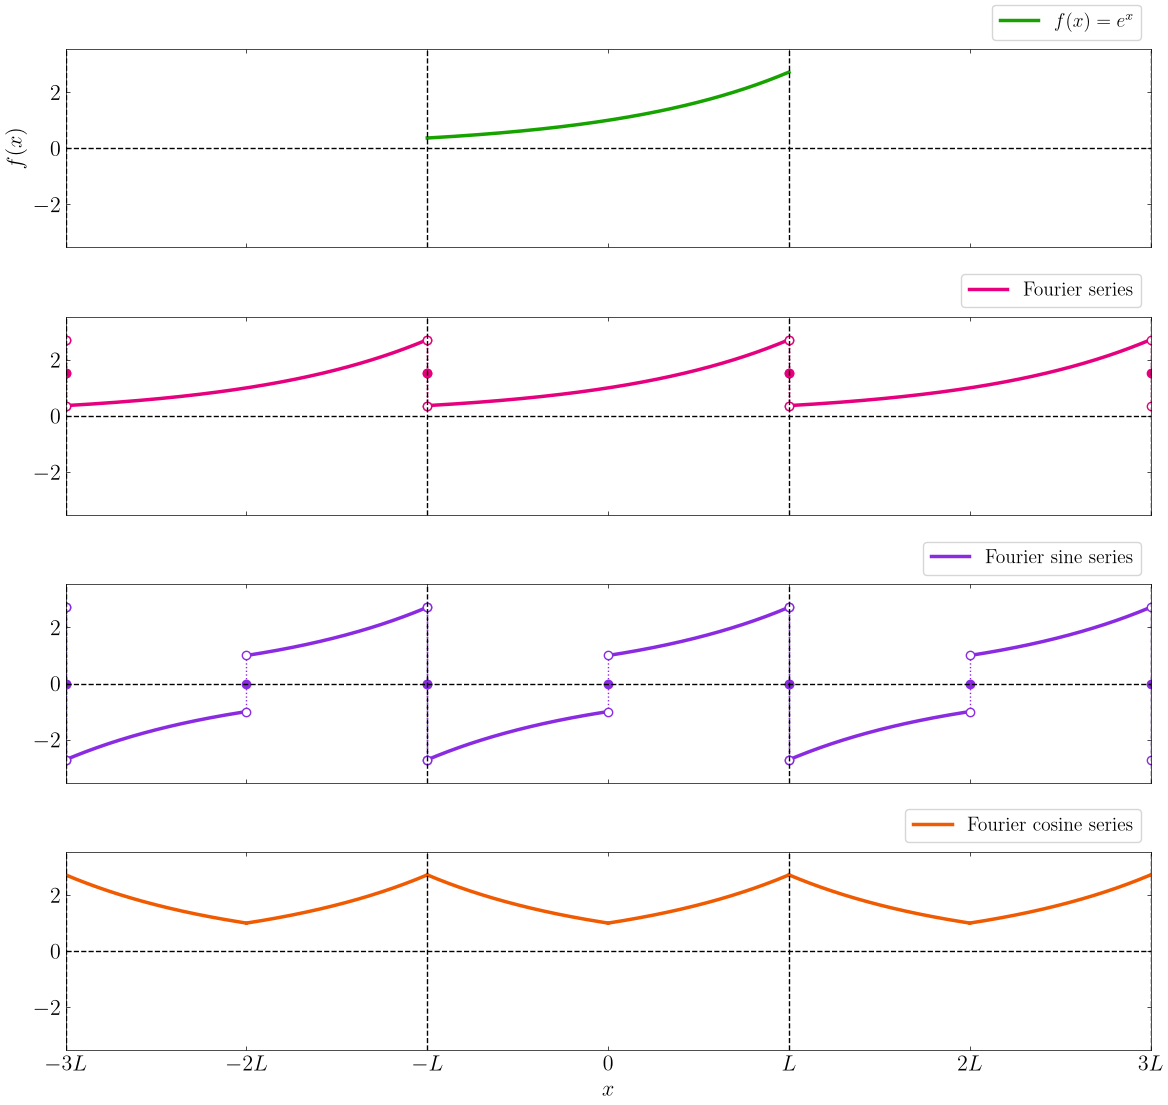

In [7]:
pieces = [(-L, L, lambda x: np.exp(x))]
plot_all_series(pieces, r"$f(x) = e^{x}$", "chap3sec3.3ex1d.pdf", [C.green, C.magenta, C.violet, C.orange])

(e)

saved chap3sec3.3ex1e.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex1e.pdf


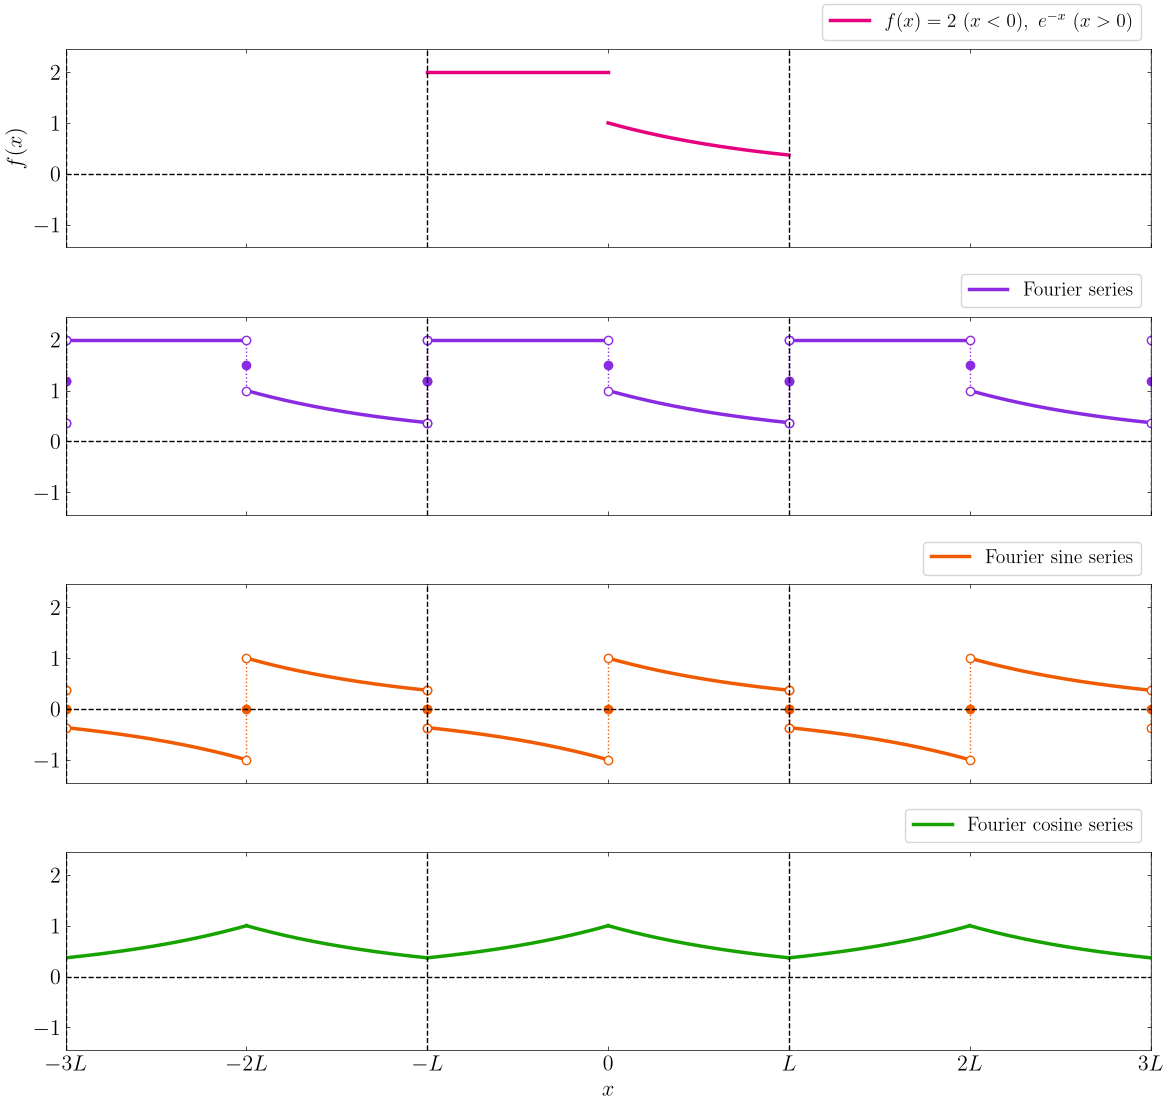

In [8]:
pieces = [(-L, 0, lambda x: 2*np.ones_like(x)), (0, L, lambda x: np.exp(-x))]
plot_all_series(pieces, r"$f(x) = 2\ (x<0),\ e^{-x}\ (x>0)$", "chap3sec3.3ex1e.pdf", [C.magenta, C.violet, C.orange, C.green])

Question 3.3.2

In [9]:
def sine_coeffs(pieces, N):
    """B_n = (2/L) int_0^L f(x) sin(n pi x/L) dx for n = 1..N, midpoint rule (numerical check only)."""
    n = np.arange(1, N + 1)[:, None]
    B = np.zeros(N)
    for a, b, g in pieces:
        x = a + (np.arange(20000) + 0.5)/20000*(b - a)
        B += 2*(b - a)/L*np.mean(g(x)*np.sin(n*np.pi*x/L), axis=1)
    return B


def plot_sine_series(pieces, label, fname, colors, B_exact, N=40):
    """Rows: f on (0, L); Fourier sine series (odd 2L-periodic extension) with the N-term partial sum overlaid.
    The closed-form B_n is asserted against numerical integration before plotting."""
    n = np.arange(1, N + 1)
    B = B_exact(n)
    assert np.allclose(B, sine_coeffs(pieces, N), atol=1e-6), 'closed-form B_n disagrees with numerical integration'

    fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    vals = []
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        vals.append(g(x))
        ax[0].plot(x, g(x), color=colors[0], linewidth=2.5)
    ax[0].plot([], [], color=colors[0], linewidth=2.5, label=label)

    vals.append(draw_periodic(ax[1], odd_extension(pieces), colors[1], 'Fourier sine series'))
    x = np.linspace(-3*L, 3*L, 3000)
    ax[1].plot(x, np.sin(np.pi*np.outer(x, n)/L) @ B, color=colors[2], linewidth=1,
               linestyle='--', label=f'{N}-term partial sum')

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=(v.min() - pad, v.max() + pad),
             xticks=L_ticks, xticklabels=L_labels)
    ax[0].set_ylabel('$f(x)$', color=FG, fontsize=16)
    ax[1].set_xlabel('$x$', color=FG, fontsize=16)
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color=FG, linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

(a)

saved chap3sec3.3ex2a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex2a.pdf


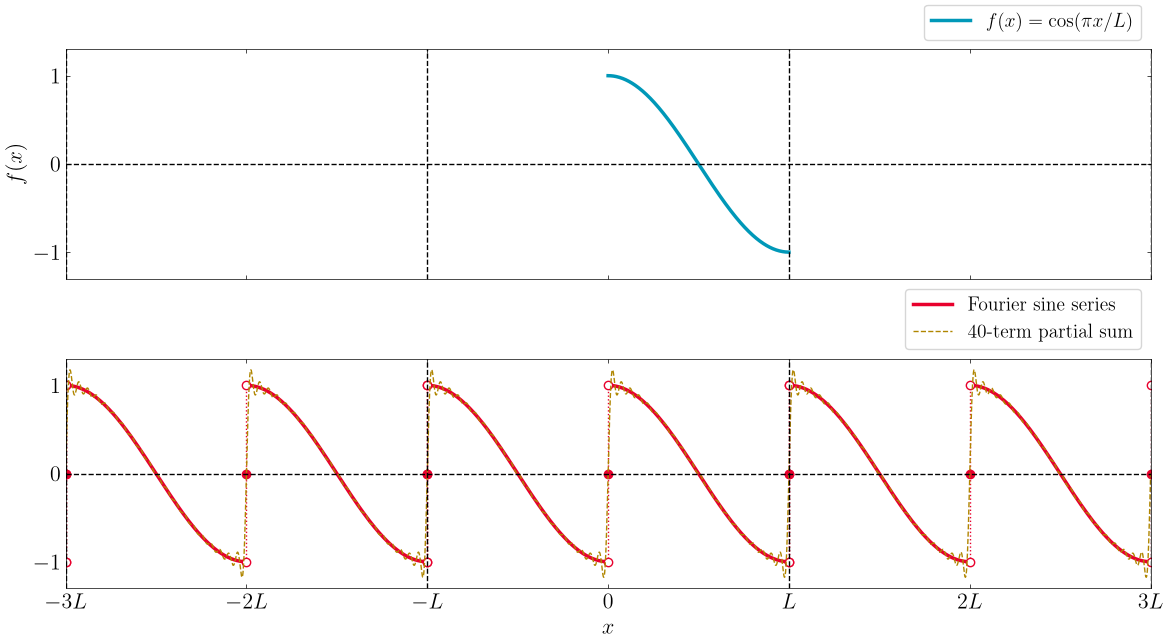

In [10]:
pieces = [(0, L, lambda x: np.cos(np.pi*x/L))]
B = lambda n: 4*n*(1 - n % 2)/(np.pi*np.maximum(n**2 - 1, 1))   # n = 1 term is 0, so the clamped denominator is harmless
plot_sine_series(pieces, r"$f(x) = \cos(\pi x/L)$", "chap3sec3.3ex2a.pdf", [C.cyan, C.red, C.yellow], B)

(b)

saved chap3sec3.3ex2b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex2b.pdf


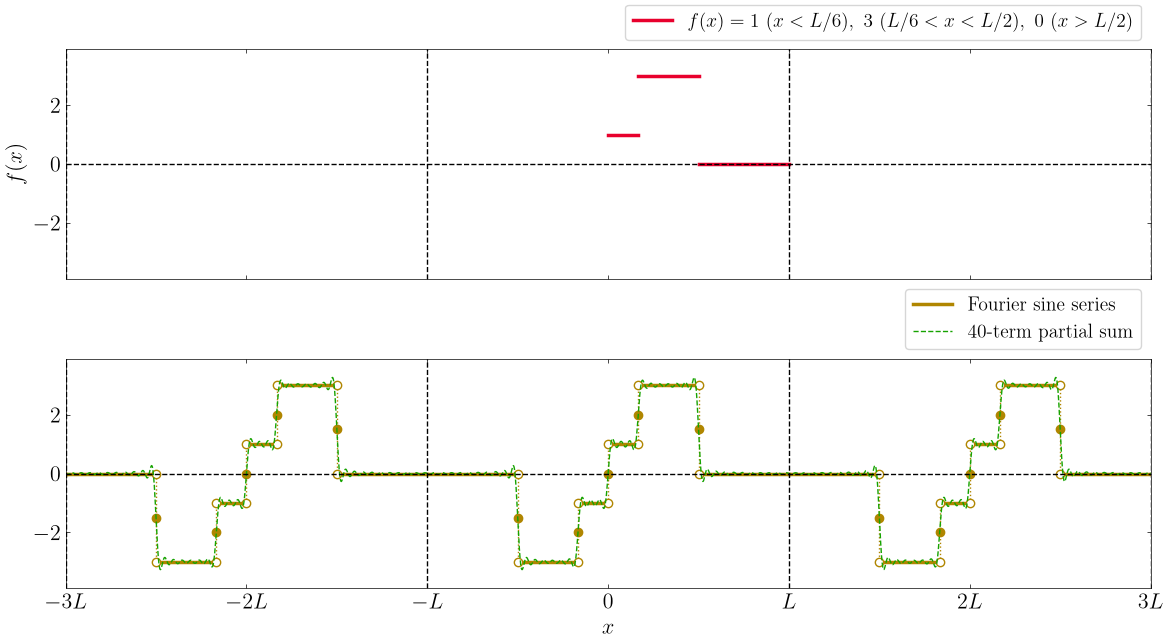

In [11]:
pieces = [(0, L/6, lambda x: np.ones_like(x)), (L/6, L/2, lambda x: 3*np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
B = lambda n: 2/(n*np.pi)*(1 + 2*np.cos(n*np.pi/6) - 3*np.cos(n*np.pi/2))
plot_sine_series(pieces, r"$f(x) = 1\ (x<L/6),\ 3\ (L/6<x<L/2),\ 0\ (x>L/2)$", "chap3sec3.3ex2b.pdf", [C.red, C.yellow, C.green], B)

(c)

saved chap3sec3.3ex2c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex2c.pdf


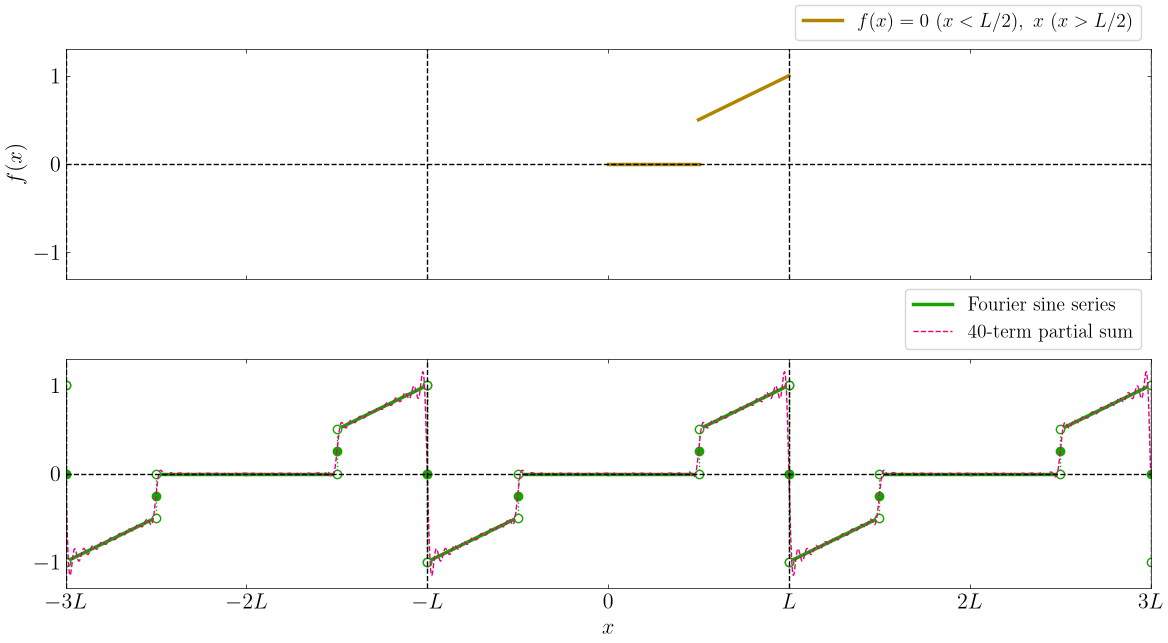

In [12]:
pieces = [(0, L/2, lambda x: np.zeros_like(x)), (L/2, L, lambda x: x)]
B = lambda n: L/(n*np.pi)*(2*(-1.0)**(n + 1) + np.cos(n*np.pi/2)) - 2*L/(n*np.pi)**2*np.sin(n*np.pi/2)
plot_sine_series(pieces, r"$f(x) = 0\ (x<L/2),\ x\ (x>L/2)$", "chap3sec3.3ex2c.pdf", [C.yellow, C.green, C.magenta], B)

(d)

saved chap3sec3.3ex2d.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex2d.pdf


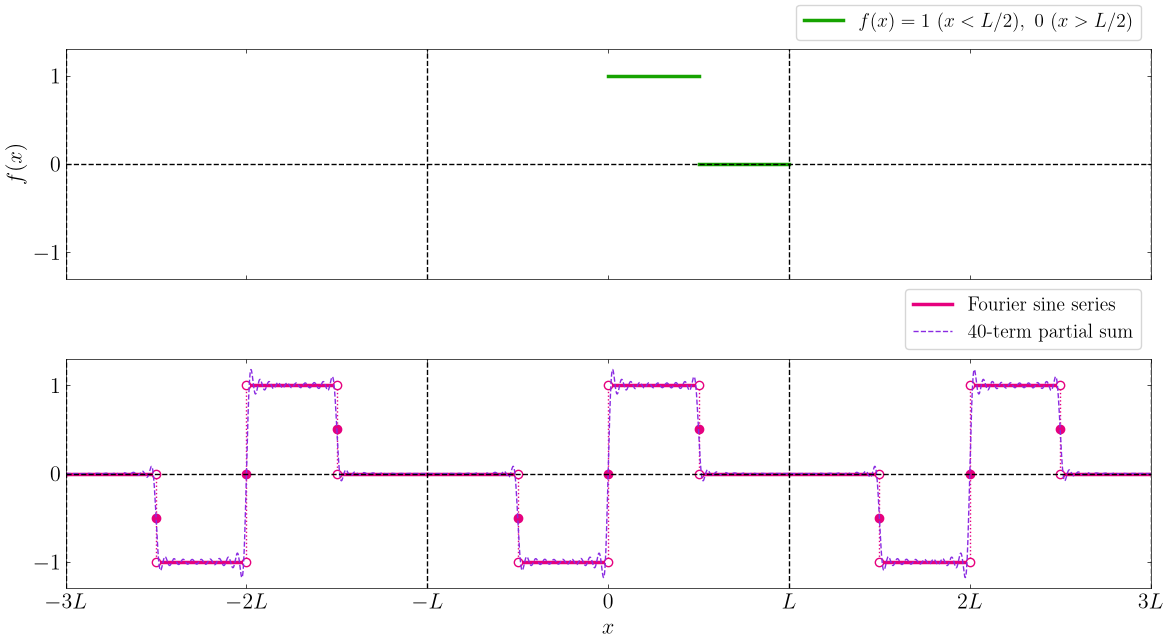

In [13]:
pieces = [(0, L/2, lambda x: np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
B = lambda n: 2/(n*np.pi)*(1 - np.cos(n*np.pi/2))
plot_sine_series(pieces, r"$f(x) = 1\ (x<L/2),\ 0\ (x>L/2)$", "chap3sec3.3ex2d.pdf", [C.green, C.magenta, C.violet], B)

Question 3.3.3

In [14]:
def plot_sine_partial_sums(pieces, label, fname, colors, B_exact, Ns=(2, 10, 50)):
    """One row per N: Fourier sine series (odd 2L-periodic extension) with the sum of the first N *nonzero* terms overlaid."""
    n = np.arange(1, 201)
    B = B_exact(n)
    assert np.allclose(B[:40], sine_coeffs(pieces, 40), atol=1e-6), 'closed-form B_n disagrees with numerical integration'
    nz = np.flatnonzero(~np.isclose(B, 0))   # indices of nonzero terms

    fig, ax = plt.subplots(len(Ns), 1, figsize=(14, 10), sharex=True)
    x = np.linspace(-3*L, 3*L, 3000)
    S = np.sin(np.pi*np.outer(x, n)/L)
    vals = []
    for a, N, c in zip(ax, Ns, colors[1:]):
        vals.append(draw_periodic(a, odd_extension(pieces), colors[0], label))
        idx = nz[:N]
        a.plot(x, S[:, idx] @ B[idx], color=c, linewidth=1.5, linestyle='--',
               label=f'{N} nonzero terms ($n \le {n[idx[-1]]}$)')

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=(v.min() - pad, v.max() + pad),
             xticks=L_ticks, xticklabels=L_labels)
    ax[-1].set_xlabel('$x$', color=FG, fontsize=16)
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color=FG, linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\david\AppData\Local\Temp\ipykernel_21588\2878524795.py:16: SyntaxWarning: invalid escape sequence '\l'
  label=f'{N} nonzero terms ($n \le {n[idx[-1]]}$)')


(a)

saved chap3sec3.3ex3a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex3a.pdf


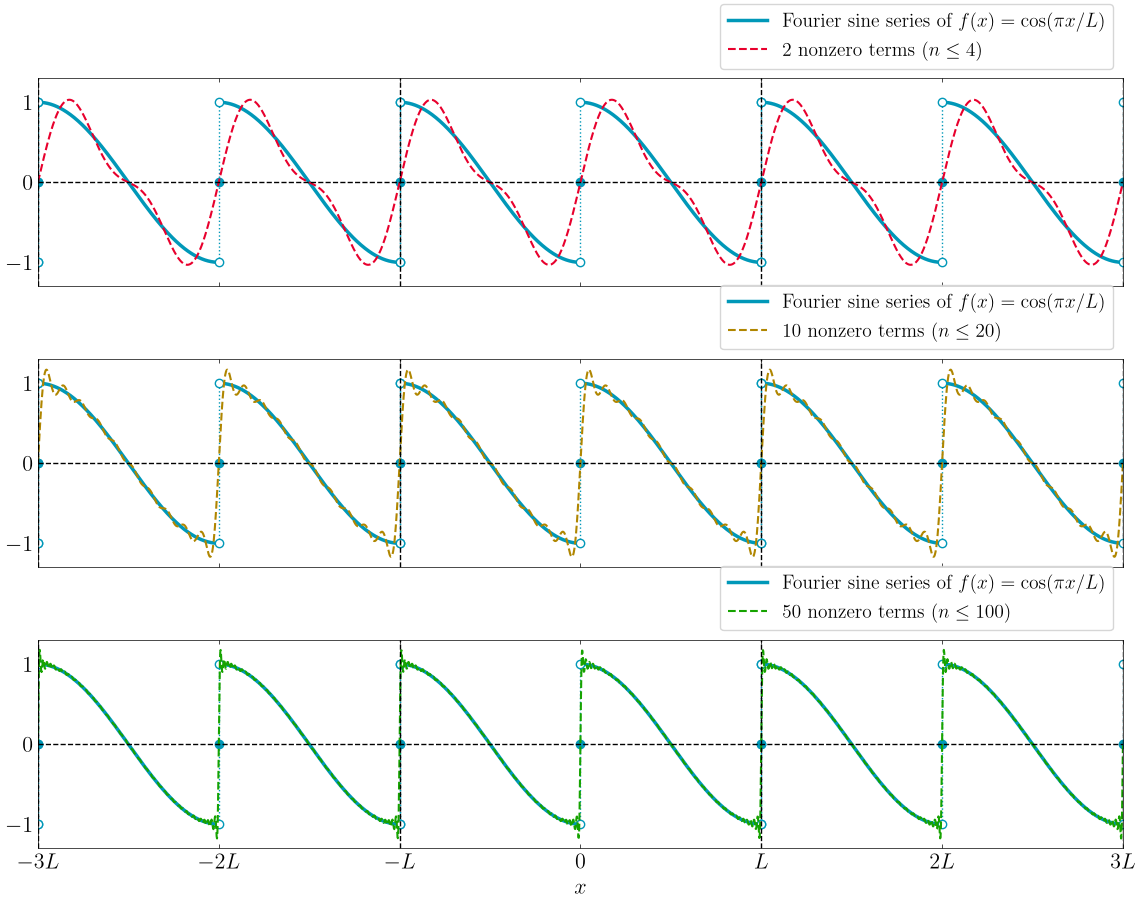

In [15]:
pieces = [(0, L, lambda x: np.cos(np.pi*x/L))]
B = lambda n: 4*n*(1 - n % 2)/(np.pi*np.maximum(n**2 - 1, 1))   # (3.3.13): B_n = 4n/(pi(n^2-1)) for even n, else 0
plot_sine_partial_sums(pieces, r"Fourier sine series of $f(x) = \cos(\pi x/L)$", "chap3sec3.3ex3a.pdf", [C.cyan, C.red, C.yellow, C.green], B)

(b)

saved chap3sec3.3ex3b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex3b.pdf


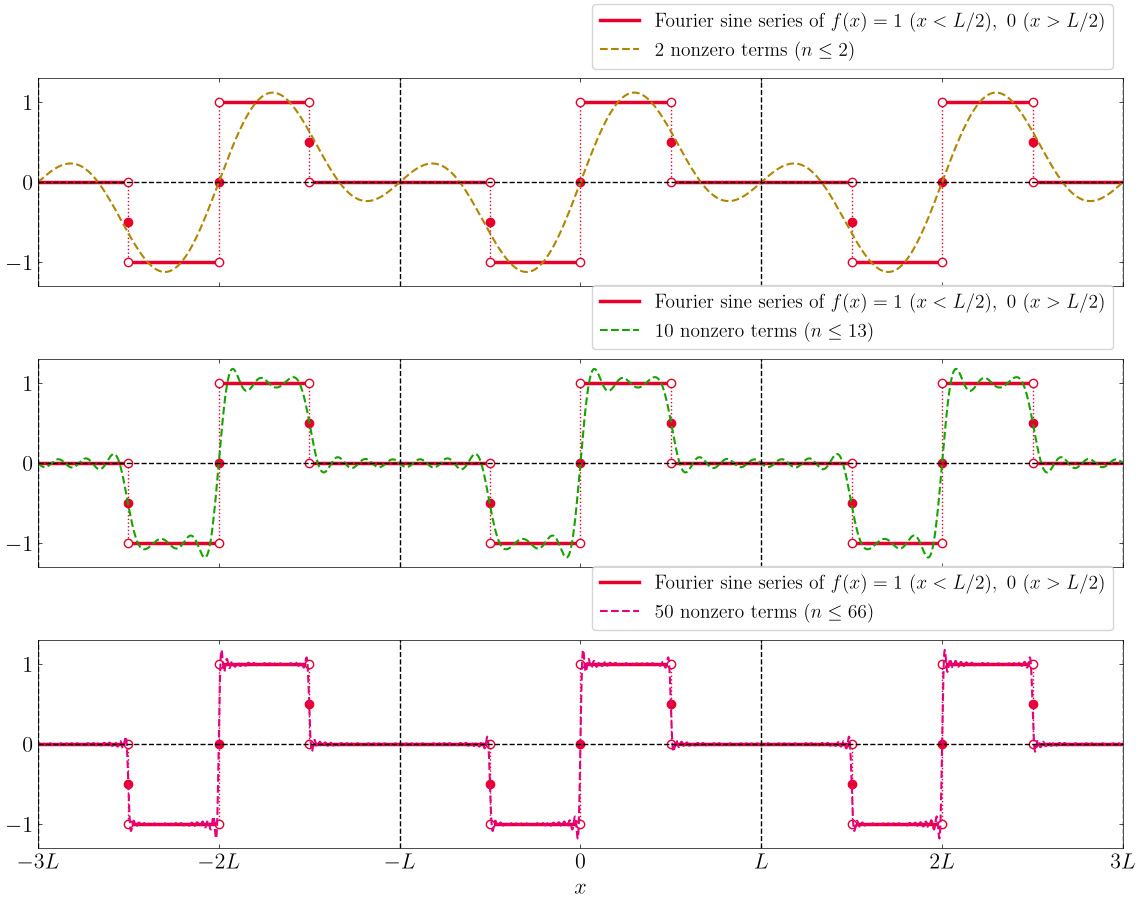

In [16]:
pieces = [(0, L/2, lambda x: np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
B = lambda n: 2/(n*np.pi)*(1 - np.cos(n*np.pi/2))
plot_sine_partial_sums(pieces, r"Fourier sine series of $f(x) = 1\ (x<L/2),\ 0\ (x>L/2)$", "chap3sec3.3ex3b.pdf", [C.red, C.yellow, C.green, C.magenta], B)

(c)

saved chap3sec3.3ex3c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex3c.pdf


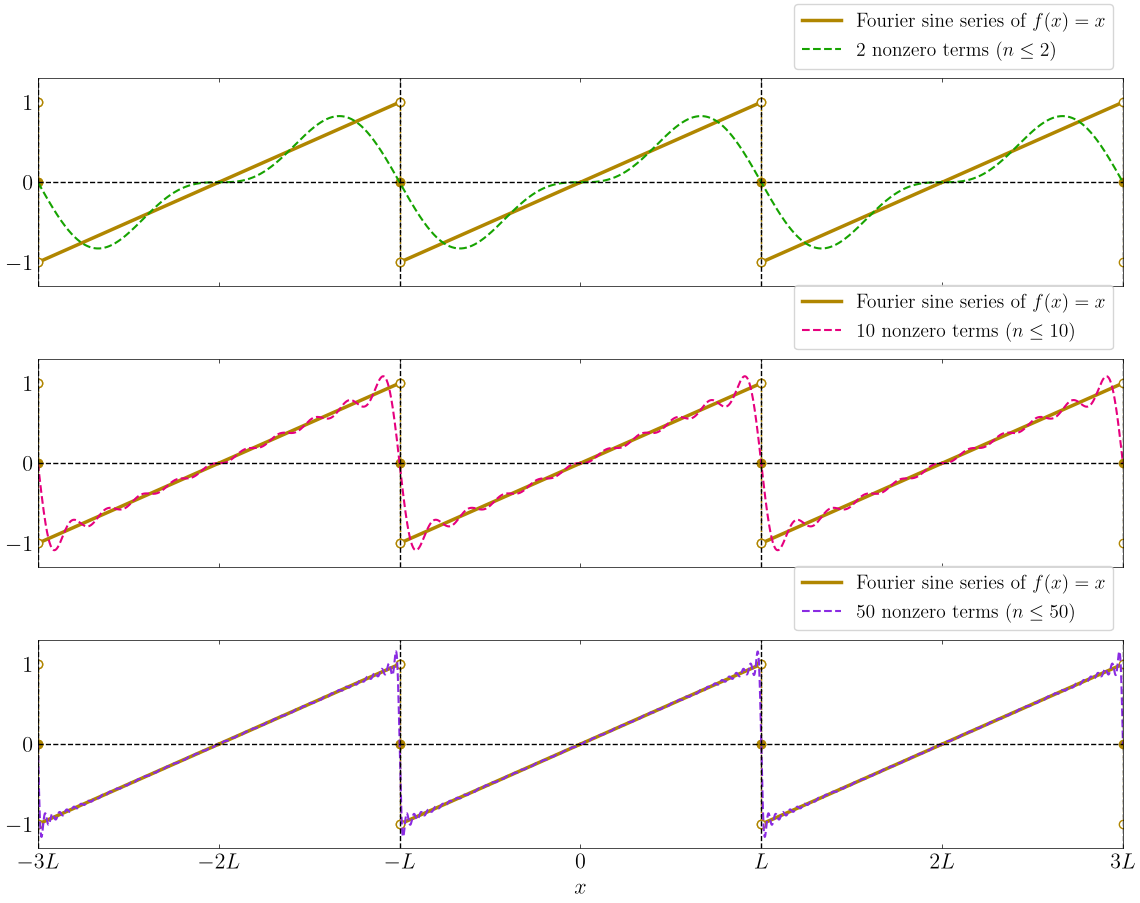

In [17]:
pieces = [(0, L, lambda x: x)]
B = lambda n: 2*L*(-1.0)**(n + 1)/(n*np.pi)   # (3.3.12)
plot_sine_partial_sums(pieces, r"Fourier sine series of $f(x) = x$", "chap3sec3.3ex3c.pdf", [C.yellow, C.green, C.magenta, C.violet], B)

Question 3.3.4

In [18]:
def cosine_coeffs(pieces, N):
    """A_0 = (1/L) int_0^L f dx, A_n = (2/L) int_0^L f cos(n pi x/L) dx for n = 0..N, midpoint rule (numerical check only)."""
    n = np.arange(0, N + 1)[:, None]
    A = np.zeros(N + 1)
    for a, b, g in pieces:
        x = a + (np.arange(20000) + 0.5)/20000*(b - a)
        A += 2*(b - a)/L*np.mean(g(x)*np.cos(n*np.pi*x/L), axis=1)
    A[0] /= 2
    return A


def plot_cosine_series(pieces, label, fname, colors, A_exact=None, N=40):
    """Rows: f on (0, L); Fourier cosine series (even 2L-periodic extension).
    If A_exact is given, it is asserted against numerical integration and the N-term partial sum is overlaid."""
    fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    vals = []
    for a, b, g in pieces:
        x = np.linspace(a, b, 400)
        vals.append(g(x))
        ax[0].plot(x, g(x), color=colors[0], linewidth=2.5)
    ax[0].plot([], [], color=colors[0], linewidth=2.5, label=label)
    vals.append(draw_periodic(ax[1], even_extension(pieces), colors[1], 'Fourier cosine series'))

    if A_exact is not None:
        n = np.arange(0, N + 1)
        A = A_exact(n)
        assert np.allclose(A, cosine_coeffs(pieces, N), atol=1e-6), 'closed-form A_n disagrees with numerical integration'
        x = np.linspace(-3*L, 3*L, 3000)
        ax[1].plot(x, np.cos(np.pi*np.outer(x, n)/L) @ A, color=colors[2], linewidth=1,
                   linestyle='--', label=f'{N}-term partial sum')

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=(v.min() - pad, v.max() + pad),
             xticks=L_ticks, xticklabels=L_labels)
    ax[0].set_ylabel('$f(x)$', color=FG, fontsize=16)
    ax[1].set_xlabel('$x$', color=FG, fontsize=16)
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color=FG, linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

saved chap3sec3.3ex4.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex4.pdf


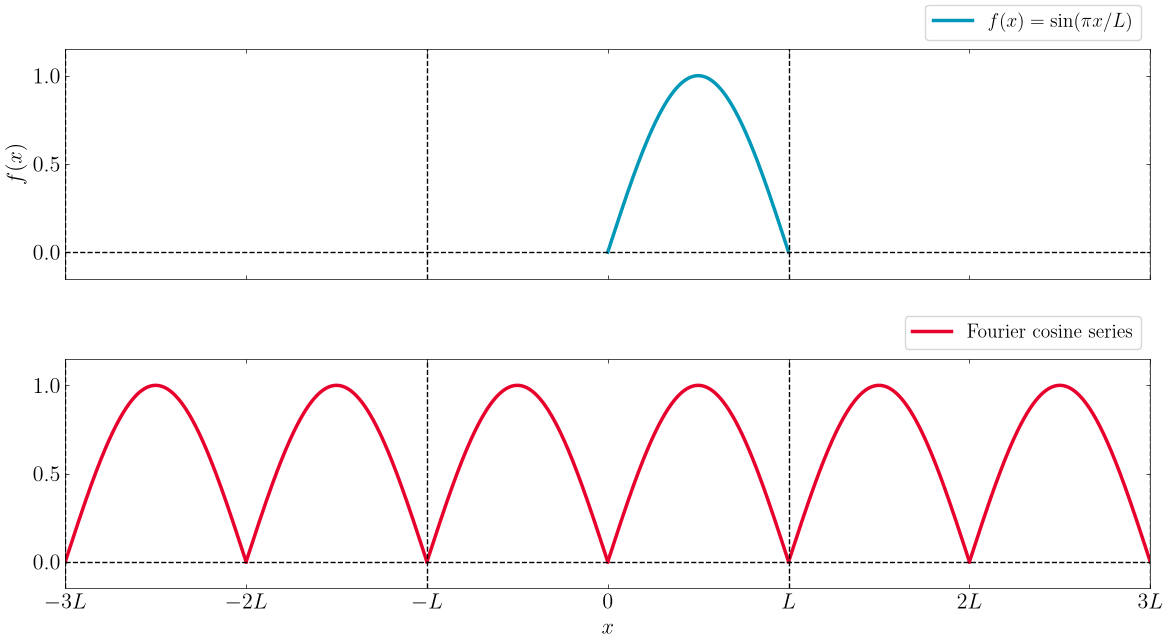

In [19]:
pieces = [(0, L, lambda x: np.sin(np.pi*x/L))]
plot_cosine_series(pieces, r"$f(x) = \sin(\pi x/L)$", "chap3sec3.3ex4.pdf", [C.cyan, C.red])

Question 3.3.5

(a)

saved chap3sec3.3ex5a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex5a.pdf


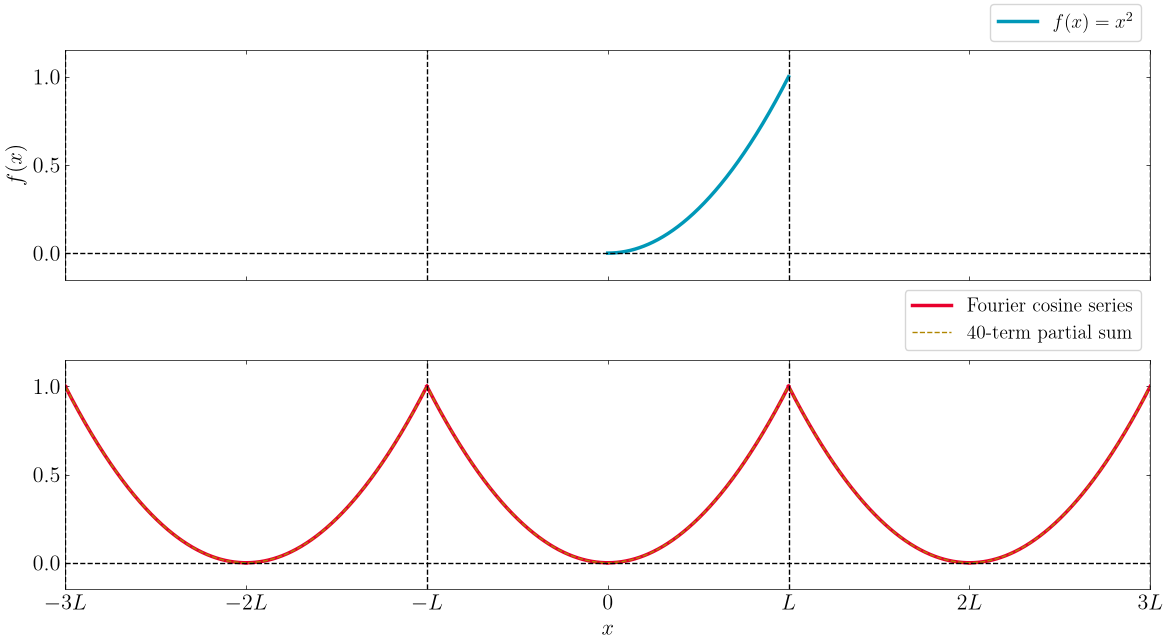

In [20]:
pieces = [(0, L, lambda x: x**2)]
A = lambda n: np.where(n == 0, L**2/3, 4*L**2*(-1.0)**n/(np.maximum(n, 1)*np.pi)**2)   # A_0 = L^2/3, A_n = 4L^2(-1)^n/(n^2 pi^2)
plot_cosine_series(pieces, r"$f(x) = x^2$", "chap3sec3.3ex5a.pdf", [C.cyan, C.red, C.yellow], A)

(b)

saved chap3sec3.3ex5b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex5b.pdf


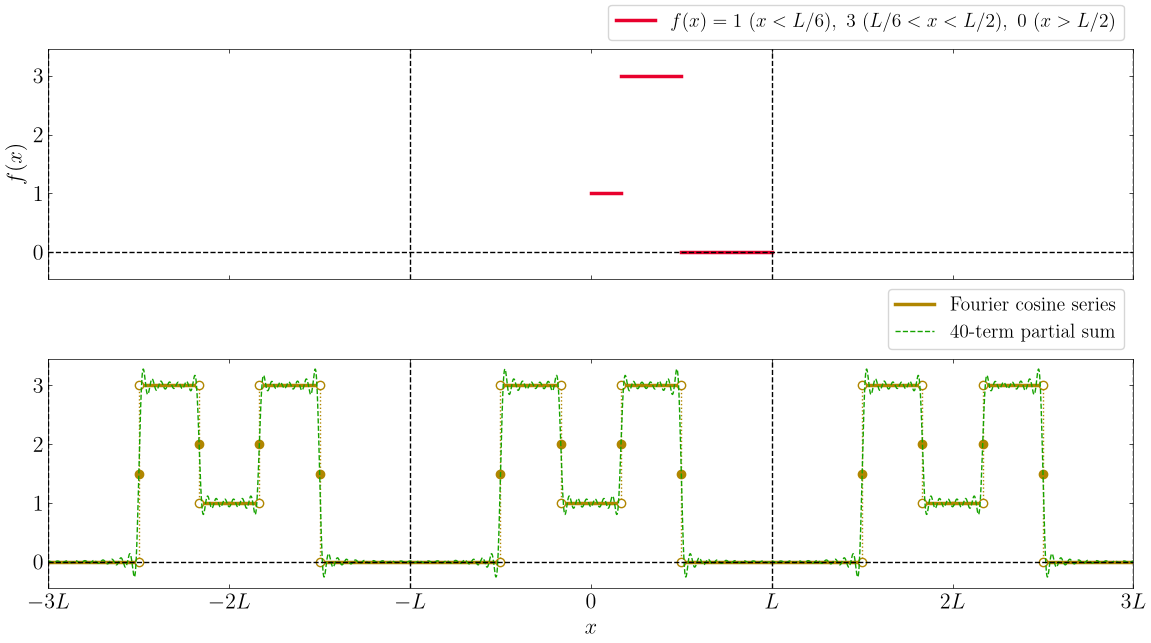

In [21]:
pieces = [(0, L/6, lambda x: np.ones_like(x)), (L/6, L/2, lambda x: 3*np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
A = lambda n: np.where(n == 0, 7/6, 2/(np.maximum(n, 1)*np.pi)*(3*np.sin(n*np.pi/2) - 2*np.sin(n*np.pi/6)))   # A_0 = 7/6, A_n = (2/(n pi))[3 sin(n pi/2) - 2 sin(n pi/6)]
plot_cosine_series(pieces, r"$f(x) = 1\ (x<L/6),\ 3\ (L/6<x<L/2),\ 0\ (x>L/2)$", "chap3sec3.3ex5b.pdf", [C.red, C.yellow, C.green], A)

(c)

saved chap3sec3.3ex5c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex5c.pdf


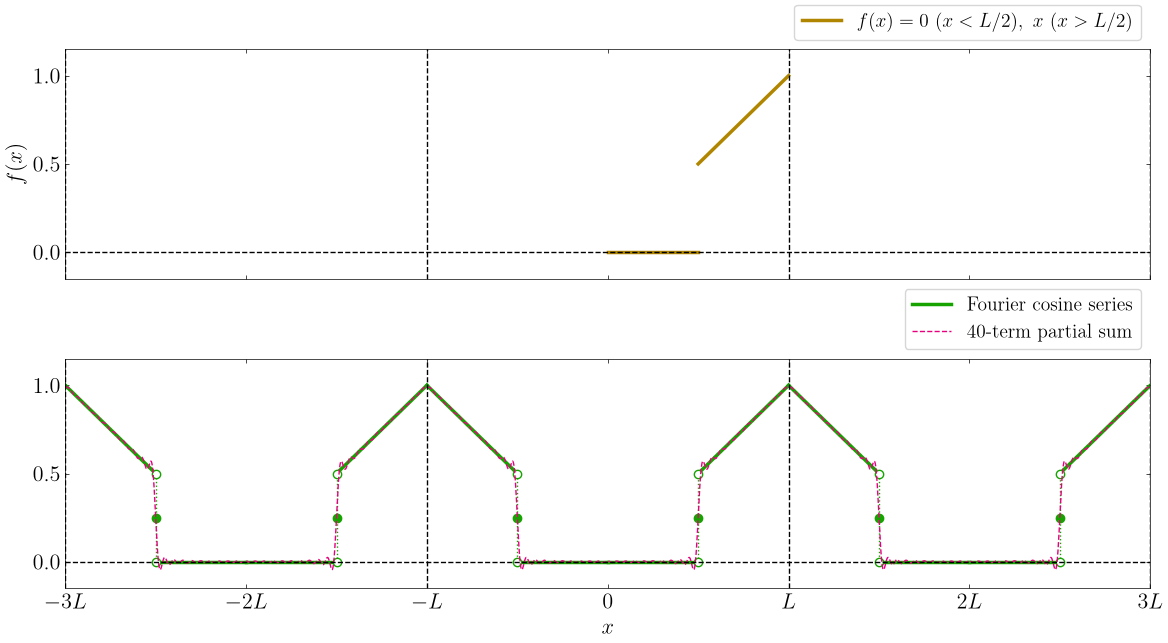

In [22]:
pieces = [(0, L/2, lambda x: np.zeros_like(x)), (L/2, L, lambda x: x)]
A = lambda n: np.where(n == 0, 3*L/8, 2*L*((-1.0)**n - np.cos(n*np.pi/2))/(np.maximum(n, 1)*np.pi)**2 - L*np.sin(n*np.pi/2)/(np.maximum(n, 1)*np.pi))   # A_0 = 3L/8, A_n = 2L[(-1)^n - cos(n pi/2)]/(n^2 pi^2) - L sin(n pi/2)/(n pi)
plot_cosine_series(pieces, r"$f(x) = 0\ (x<L/2),\ x\ (x>L/2)$", "chap3sec3.3ex5c.pdf", [C.yellow, C.green, C.magenta], A)

Question 3.3.6

In [23]:
def plot_cosine_partial_sums(pieces, label, fname, colors, A_exact, Ns=(2, 10, 50)):
    """One row per N: Fourier cosine series (even 2L-periodic extension) with the sum of the first N *nonzero* terms (A_0 counted) overlaid."""
    n = np.arange(0, 201)
    A = A_exact(n)
    assert np.allclose(A[:41], cosine_coeffs(pieces, 40), atol=1e-6), 'closed-form A_n disagrees with numerical integration'
    nz = np.flatnonzero(~np.isclose(A, 0))   # indices of nonzero terms

    fig, ax = plt.subplots(len(Ns), 1, figsize=(14, 10), sharex=True)
    x = np.linspace(-3*L, 3*L, 3000)
    C = np.cos(np.pi*np.outer(x, n)/L)
    vals = []
    for a, N, c in zip(ax, Ns, colors[1:]):
        vals.append(draw_periodic(a, even_extension(pieces), colors[0], label))
        idx = nz[:N]
        a.plot(x, C[:, idx] @ A[idx], color=c, linewidth=1.5, linestyle='--',
               label=f'{N} nonzero terms ($n \le {n[idx[-1]]}$)')

    v = np.concatenate(vals)
    pad = 0.15*(v.max() - v.min() or 1)
    style_ax(ax, xlabel='', ylabel='', xlim=(-3*L, 3*L), ylim=(v.min() - pad, v.max() + pad),
             xticks=L_ticks, xticklabels=L_labels)
    ax[-1].set_xlabel('$x$', color=FG, fontsize=16)
    for a in ax:
        a.axhline(0, color=FG, linestyle='--', linewidth=1)
        for k in range(-3, 4, 2):
            a.axvline(k*L, color=FG, linestyle='--', linewidth=1)
        a.legend(frameon=True, fontsize=14, loc='lower right', bbox_to_anchor=(1, 1.0))

    fig.subplots_adjust(hspace=0.35)
    savefig(fig, fname, bbox_inches=None)
    plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\david\AppData\Local\Temp\ipykernel_21588\3390565490.py:16: SyntaxWarning: invalid escape sequence '\l'
  label=f'{N} nonzero terms ($n \le {n[idx[-1]]}$)')


(a)

saved chap3sec3.3ex6a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex6a.pdf


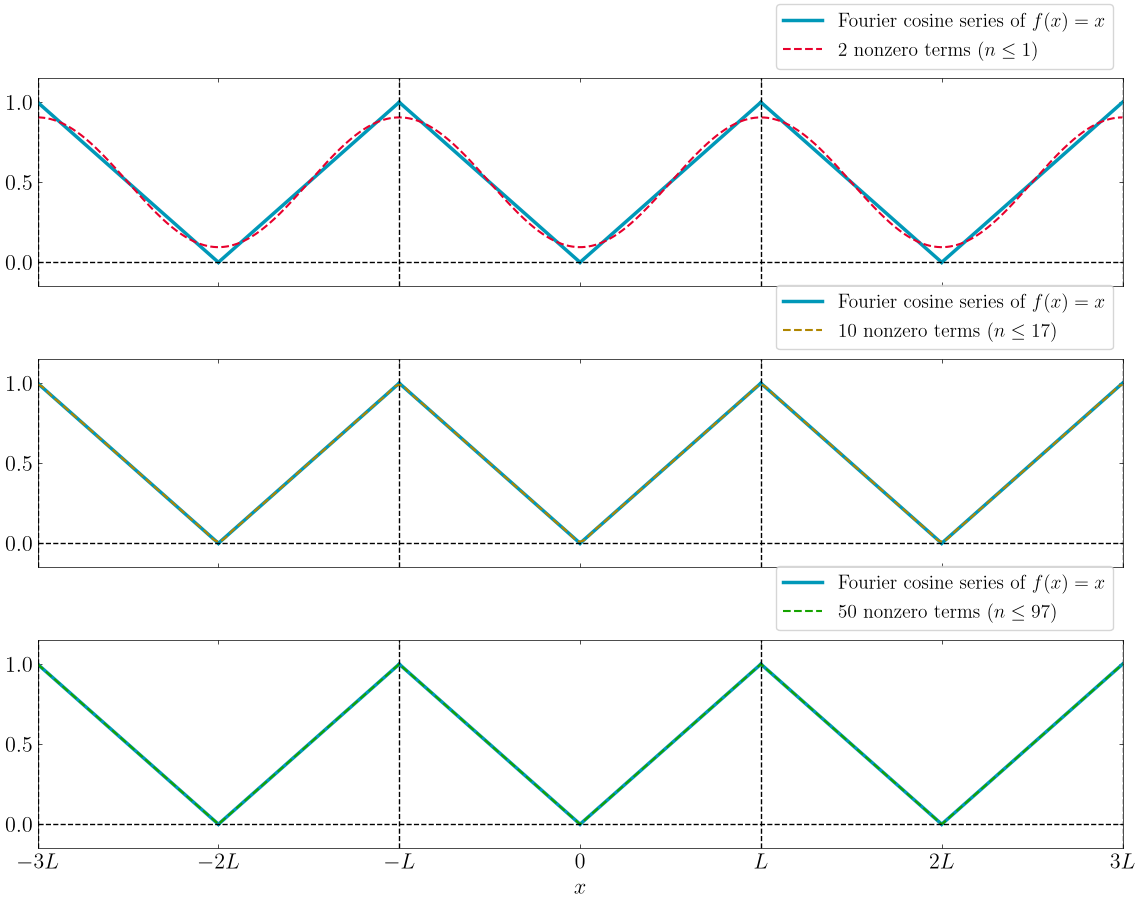

In [24]:
pieces = [(0, L, lambda x: x)]
A = lambda n: np.where(n == 0, L/2, -4*L*(n % 2)/(np.maximum(n, 1)*np.pi)**2)   # (3.3.22)-(3.3.23): A_0 = L/2, A_n = -4L/(n^2 pi^2) for odd n, else 0
plot_cosine_partial_sums(pieces, r"Fourier cosine series of $f(x) = x$", "chap3sec3.3ex6a.pdf", [C.cyan, C.red, C.yellow, C.green], A)

(b)

saved chap3sec3.3ex6b.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex6b.pdf


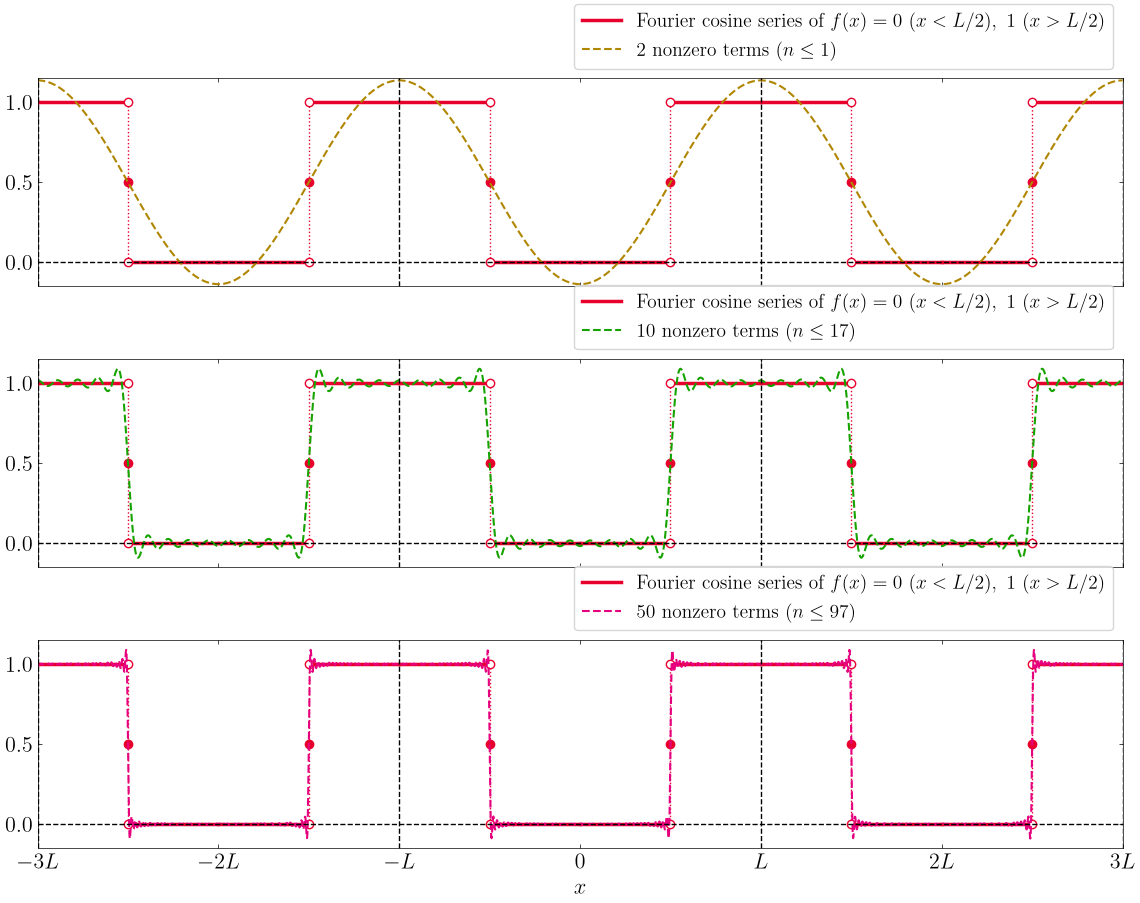

In [25]:
pieces = [(0, L/2, lambda x: np.zeros_like(x)), (L/2, L, lambda x: np.ones_like(x))]
A = lambda n: np.where(n == 0, 1/2, -2*np.sin(n*np.pi/2)/(np.maximum(n, 1)*np.pi))   # A_0 = 1/2, A_n = -(2/(n pi)) sin(n pi/2)
plot_cosine_partial_sums(pieces, r"Fourier cosine series of $f(x) = 0\ (x<L/2),\ 1\ (x>L/2)$", "chap3sec3.3ex6b.pdf", [C.red, C.yellow, C.green, C.magenta], A)

(c)

saved chap3sec3.3ex6c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex6c.pdf


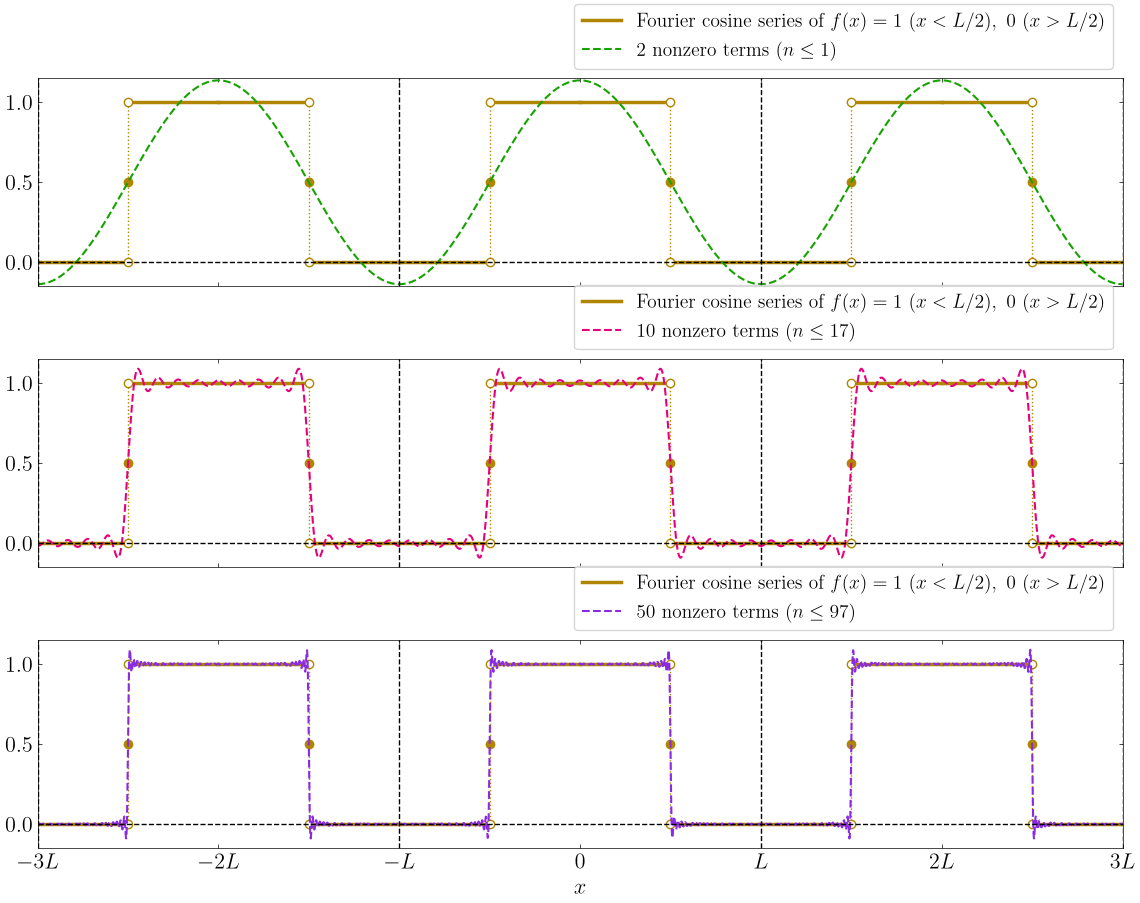

In [26]:
pieces = [(0, L/2, lambda x: np.ones_like(x)), (L/2, L, lambda x: np.zeros_like(x))]
A = lambda n: np.where(n == 0, 1/2, 2*np.sin(n*np.pi/2)/(np.maximum(n, 1)*np.pi))   # (b) + (c) = 1, so A_0 = 1 - 1/2, A_n = -(A_n of b)
plot_cosine_partial_sums(pieces, r"Fourier cosine series of $f(x) = 1\ (x<L/2),\ 0\ (x>L/2)$", "chap3sec3.3ex6c.pdf", [C.yellow, C.green, C.magenta, C.violet], A)

Question 3.3.8

(c)

saved chap3sec3.3ex8c.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex8c.pdf


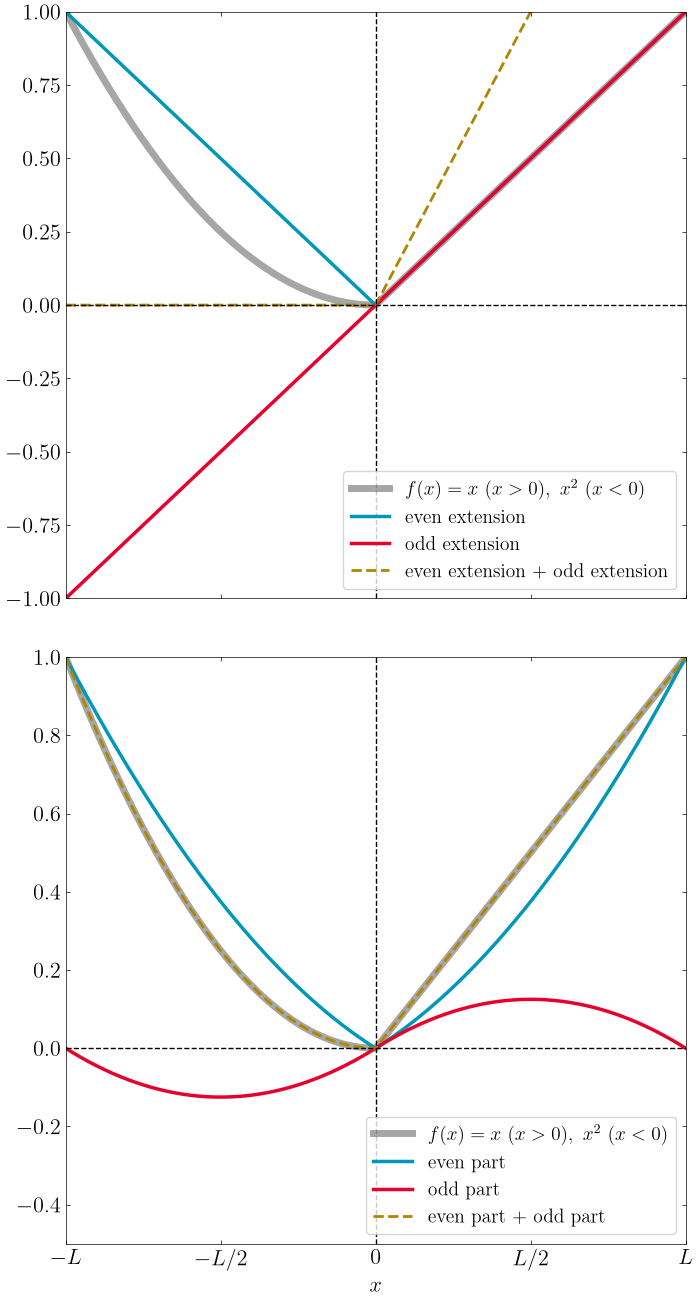

In [27]:
f = lambda x: np.where(x > 0, x, x**2)
x = np.linspace(-L, L, 801)
even_ext, odd_ext = f(np.abs(x)), np.sign(x)*f(np.abs(x))      # f(|x|), sgn(x) f(|x|)
even_part, odd_part = (f(x) + f(-x))/2, (f(x) - f(-x))/2      # [f(x) + f(-x)]/2, [f(x) - f(-x)]/2

fig, ax = plt.subplots(2, 1, figsize=(8, 16), sharex=True)
colors = [C.cyan, C.red, C.yellow]
for a, (e, o, name) in zip(ax, [(even_ext, odd_ext, 'extension'), (even_part, odd_part, 'part')]):
    a.plot(x, f(x), color=FG, linewidth=5, alpha=0.35, label=r'$f(x) = x\ (x>0),\ x^2\ (x<0)$')
    a.plot(x, e, color=colors[0], linewidth=2.5, label=f'even {name}')
    a.plot(x, o, color=colors[1], linewidth=2.5, label=f'odd {name}')
    a.plot(x, e + o, color=colors[2], linewidth=2, linestyle='--', label=f'even {name} + odd {name}')
    a.axhline(0, color=FG, linestyle='--', linewidth=1)
    a.axvline(0, color=FG, linestyle='--', linewidth=1)
    a.legend(frameon=True, fontsize=14, loc='lower right')

style_ax(ax, xlabel='', ylabel='', xlim=(-L, L),
         xticks=[-L, -L/2, 0, L/2, L], xticklabels=[r'$-L$', r'$-L/2$', r'$0$', r'$L/2$', r'$L$'])
ax[0].set_ylim(-1, 1)
ax[1].set_ylim(-0.5, 1)
ax[1].set_xlabel('$x$', color=FG, fontsize=16)
fig.subplots_adjust(hspace=0.1)
savefig(fig, "chap3sec3.3ex8c.pdf", bbox_inches=None)
plt.show()

Question 3.3.12

(a)

saved chap3sec3.3ex12a.pdf -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\apde\chap3\sec3.3\chap3sec3.3ex12a.pdf


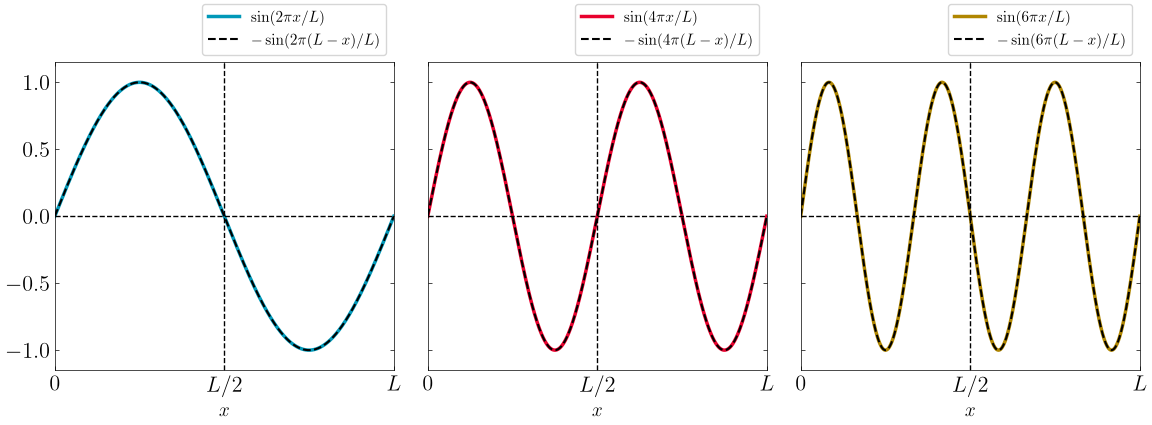

In [28]:
x = np.linspace(0, L, 801)
ns = [2, 4, 6]
colors = [C.cyan, C.red, C.yellow]

fig, ax = plt.subplots(1, len(ns), figsize=(14, 4), sharey=True)
for a, n, c in zip(ax, ns, colors):
    a.plot(x, np.sin(n*np.pi*x/L), color=c, linewidth=2.5, label=rf'$\sin({n}\pi x/L)$')
    a.plot(x, -np.sin(n*np.pi*(L - x)/L), color=FG, linewidth=1.5, linestyle='--',
           label=rf'$-\sin({n}\pi (L - x)/L)$')   # reflect about x = L/2 and negate: identical
    a.axhline(0, color=FG, linestyle='--', linewidth=1)
    a.axvline(L/2, color=FG, linestyle='--', linewidth=1)
    a.legend(frameon=True, fontsize=11, loc='lower right', bbox_to_anchor=(1, 1.0))

style_ax(ax, xlabel='', ylabel='', xlim=(0, L), ylim=(-1.15, 1.15),
         xticks=[0, L/2, L], xticklabels=[r'$0$', r'$L/2$', r'$L$'])
for a in ax:
    a.set_xlabel('$x$', color=FG, fontsize=14)
fig.subplots_adjust(wspace=0.1)
savefig(fig, "chap3sec3.3ex12a.pdf", bbox_inches=None)
plt.show()